# Audio Spectrogram Transformer + Metadata Fusion

Multimodal model combining:
- **AST branch**: Audio Spectrogram Transformer — 128×128 mel spectrogram split into 16×16 patches (64 patches), processed by a Transformer encoder
- **Metadata branch**: MLP over genre (one-hot), gain, explicit, duration, num_contributors, track_position
- **Late fusion**: concatenated CLS embedding + metadata embedding → CORN ordinal head

Excluded features: `rank` (0.994 correlation with target — data leakage), `bpm` (66% missing/zero)

In [20]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from coral_pytorch.losses import corn_loss
from coral_pytorch.dataset import corn_label_from_logits

## Data Loading

In [21]:
df = pd.read_csv("../data/all_tracks_clean.csv")

image_data = np.load("../data/spectrogram_tensors.npz")
X       = image_data["X"]        # (N, 1, 128, 128) single-channel mel spectrograms
indices = image_data["indices"]

print(f"Spectrograms: {X.shape}")
df.head()

Spectrograms: (7549, 1, 128, 128)


,genre,id,title,artist,album,duration_sec,rank,explicit,isrc,track_position,bpm,gain,contributors,num_contributors,tier
0,Pop,3602074142,Choosin' Texas,Ella Langley,Choosin' Texas,232,831096,False,USSM12504190,1,0.0,-8.3,Ella Langley (Main),1,9
1,Pop,3763842212,I Just Might,Bruno Mars,I Just Might,213,995346,False,USAT22509144,1,0.0,-10.4,Bruno Mars (Main),1,10
2,Pop,3503857201,Man I Need,Olivia Dean,Man I Need,184,991622,False,GBUM72503089,1,0.0,-8.7,Olivia Dean (Main),1,10
3,Pop,3881984641,American Girls,Harry Styles,"Kiss All The Time. Disco, Occasionally.",213,997062,False,USSM12600097,2,0.0,-8.3,Harry Styles (Main),1,10
4,Pop,3579685911,The Fate of Ophelia,Taylor Swift,The Life of a Showgirl,226,836426,False,USUG12506436,1,0.0,-8.5,Taylor Swift (Main),1,9


In [22]:
# Align metadata to the subset of tracks that have spectrograms
df_aligned = df.iloc[indices].reset_index(drop=True)

# Genre: one-hot encoding (27 classes)
genre_dummies = pd.get_dummies(df_aligned["genre"], prefix="genre").astype(np.float32)
n_genre_cols  = genre_dummies.shape[1]
print(f"Genre classes ({n_genre_cols}):", list(genre_dummies.columns))

# Numeric and binary features
# rank excluded: 0.994 correlation with tier (tier is binned rank — direct leakage)
# bpm excluded:  66% of values are 0 (unreliable / missing)
num_feats = df_aligned[["gain", "duration_sec", "num_contributors", "track_position"]].copy().astype(np.float32)
num_feats["explicit"] = df_aligned["explicit"].astype(np.float32)

meta_raw = pd.concat([genre_dummies, num_feats], axis=1).values.astype(np.float32)
meta_dim = meta_raw.shape[1]
print(f"Total metadata feature dim: {meta_dim}")

Genre classes (27): ['genre_African Music', 'genre_Alternative', 'genre_Asian Music', 'genre_Blues', 'genre_Brazilian Music', 'genre_Christian', 'genre_Classical', 'genre_Country', 'genre_Cumbia', 'genre_Dance', 'genre_Electro', 'genre_Films Games', 'genre_Folk', 'genre_Indian Music', 'genre_Jazz', 'genre_Kids', 'genre_Latin Music', 'genre_Metal', 'genre_Pop', 'genre_Rap Hip Hop', 'genre_Reggae', 'genre_Reggaeton', 'genre_RnB', 'genre_Rock', 'genre_Salsa', 'genre_Soul Funk', 'genre_Traditional Mexicano']
Total metadata feature dim: 32


In [23]:
y_raw = df_aligned["tier"].values.astype(int)

# Map 10 tiers to 5 buckets: tiers 1-2 → 0, 3-4 → 1, 5-6 → 2, 7-8 → 3, 9-10 → 4
y_bucketed = (y_raw - 1) // 2

classes     = np.unique(y_bucketed)
num_classes = len(classes)
label_map   = {c: i for i, c in enumerate(sorted(classes))}
y           = np.array([label_map[v] for v in y_bucketed])

bucket_ranges = ["1-2", "3-4", "5-6", "7-8", "9-10"]
for label_idx, orig_bucket in enumerate(sorted(classes)):
    print(f"label {label_idx} (tiers {bucket_ranges[orig_bucket]}): {(y == label_idx).sum()} samples")

label 0 (tiers 1-2): 2234 samples
label 1 (tiers 3-4): 1707 samples
label 2 (tiers 5-6): 1834 samples
label 3 (tiers 7-8): 1236 samples
label 4 (tiers 9-10): 538 samples


## Dataset

In [24]:
class SpectrogramMetaDataset(Dataset):
    def __init__(self, spectrograms, metadata, labels, augment=False):
        self.specs   = torch.tensor(spectrograms, dtype=torch.float32)
        self.meta    = torch.tensor(metadata,     dtype=torch.float32)
        self.labels  = torch.tensor(labels,       dtype=torch.long)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        spec = self.specs[idx].clone()
        if self.augment:
            # Frequency masking: zero out a random band of mel bins (axis 1)
            f_width = random.randint(0, 20)
            f0      = random.randint(0, spec.shape[1] - f_width)
            spec[:, f0:f0 + f_width, :] = 0
            # Time masking: zero out a random band of time steps (axis 2)
            t_width = random.randint(0, 20)
            t0      = random.randint(0, spec.shape[2] - t_width)
            spec[:, :, t0:t0 + t_width] = 0
        return spec, self.meta[idx], self.labels[idx]

In [25]:
# Train / Val / Test split (70 / 15 / 15) — same seed as baseline for comparability
idx_all = np.arange(len(y))
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all, y, test_size=0.3, random_state=6500
)
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp, y_temp, test_size=0.5, random_state=6500
)

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]

meta_train = meta_raw[idx_train].copy()
meta_val   = meta_raw[idx_val].copy()
meta_test  = meta_raw[idx_test].copy()

# Fit StandardScaler on training data only; skip one-hot genre columns
scaler = StandardScaler()
meta_train[:, n_genre_cols:] = scaler.fit_transform(meta_train[:, n_genre_cols:])
meta_val[:, n_genre_cols:]   = scaler.transform(meta_val[:, n_genre_cols:])
meta_test[:, n_genre_cols:]  = scaler.transform(meta_test[:, n_genre_cols:])

print("Train:", X_train.shape, meta_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   meta_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  meta_test.shape,  y_test.shape)

Train: (5284, 1, 128, 128) (5284, 32) (5284,)
Val:   (1132, 1, 128, 128) (1132, 32) (1132,)
Test:  (1133, 1, 128, 128) (1133, 32) (1133,)


In [26]:
train_ds = SpectrogramMetaDataset(X_train, meta_train, y_train, augment=True)
val_ds   = SpectrogramMetaDataset(X_val,   meta_val,   y_val,   augment=False)
test_ds  = SpectrogramMetaDataset(X_test,  meta_test,  y_test,  augment=False)

# WeightedRandomSampler: upsample minority buckets so each class is seen equally
class_counts   = np.bincount(y_train)
class_weights  = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[y] for y in y_train], dtype=torch.float)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,   num_workers=0)

## Model Architecture

In [ ]:
class PatchEmbedding(nn.Module):
    """Split spectrogram into non-overlapping patches via Conv2d and project each to d_model."""

    def __init__(self, img_size=128, patch_size=16, in_channels=1, d_model=256):
        super().__init__()
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"
        self.n_patches = (img_size // patch_size) ** 2  # 64 for 128/16
        # Conv2d with kernel=stride=patch_size is an efficient non-overlapping patch projection
        self.proj = nn.Conv2d(in_channels, d_model, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # (B, C, H, W) -> (B, d_model, n_h, n_w) -> (B, n_patches, d_model)
        x = self.proj(x)
        B, D, nh, nw = x.shape
        return x.flatten(2).transpose(1, 2)


class AudioSpectrogramTransformer(nn.Module):
    """
    AST: treat the mel spectrogram as a sequence of 16x16 patches (64 total),
    prepend a learnable CLS token, run through Transformer encoder blocks,
    and return the CLS embedding as the audio representation.
    """

    def __init__(
        self,
        img_size=128,
        patch_size=16,
        in_channels=1,
        d_model=256,
        num_heads=4,
        num_layers=6,
        mlp_dim=1024,
        dropout=0.1,
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, d_model)
        n_patches = self.patch_embed.n_patches  # 64

        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        self.pos_drop  = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            batch_first=True,
            norm_first=True,   # Pre-LayerNorm for more stable training
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        # Small std initialisation keeps early gradients healthy
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B   = x.size(0)
        x   = self.patch_embed(x)               # (B, 64, d_model)
        cls = self.cls_token.expand(B, -1, -1)  # (B,  1, d_model)
        x   = torch.cat([cls, x], dim=1)        # (B, 65, d_model)
        x   = self.pos_drop(x + self.pos_embed)
        x   = self.norm(self.transformer(x))
        return x[:, 0]                          # CLS token -> (B, d_model)

In [28]:
class MetadataMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, output_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class ASTFusionModel(nn.Module):
    """
    Late-fusion multimodal model:
      - AST branch processes mel spectrograms -> 256-dim CLS embedding
      - Metadata MLP processes tabular features -> 64-dim embedding
      - Concatenated (320-dim) -> fusion MLP -> CORN ordinal head (num_classes - 1 outputs)
    """

    def __init__(self, meta_input_dim, num_classes, ast_d_model=256, meta_output_dim=64):
        super().__init__()
        self.ast      = AudioSpectrogramTransformer(d_model=ast_d_model)
        self.meta_mlp = MetadataMLP(meta_input_dim, output_dim=meta_output_dim)

        fusion_dim = ast_d_model + meta_output_dim  # 320
        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes - 1),  # CORN: C-1 sigmoid outputs
        )

    def forward(self, spec, meta):
        audio_feat = self.ast(spec)                              # (B, 256)
        meta_feat  = self.meta_mlp(meta)                        # (B,  64)
        fused      = torch.cat([audio_feat, meta_feat], dim=1)  # (B, 320)
        return self.fusion_head(fused)

## Training

In [29]:
device = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else
    "cpu"
)
print(f"Using device: {device}")

model = ASTFusionModel(meta_input_dim=meta_dim, num_classes=num_classes).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

# Differential LRs:
# AST body gets a lower LR (transformers are sensitive to large updates early on)
# Metadata MLP + fusion head get a higher LR (trained from scratch, converge faster)
ast_params  = list(model.ast.parameters())
head_params = list(model.meta_mlp.parameters()) + list(model.fusion_head.parameters())

optimizer = torch.optim.AdamW(
    [{"params": ast_params,  "lr": 1e-4},
     {"params": head_params, "lr": 5e-4}],
    weight_decay=1e-3,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

Using device: mps
Trainable parameters: 4,876,100


/Users/akshayarun/.pyenv/versions/3.10.13/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [30]:
def train_epoch(model, loader):
    model.train()
    total_loss, total_correct = 0, 0
    for spec, meta, labels in loader:
        spec, meta, labels = spec.to(device), meta.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(spec, meta)
        loss   = corn_loss(logits, labels, num_classes)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item()
        total_correct += (corn_label_from_logits(logits) == labels).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)


def eval_epoch(model, loader):
    model.eval()
    total_loss, total_correct = 0, 0
    with torch.no_grad():
        for spec, meta, labels in loader:
            spec, meta, labels = spec.to(device), meta.to(device), labels.to(device)
            logits = model(spec, meta)
            total_loss    += corn_loss(logits, labels, num_classes).item()
            total_correct += (corn_label_from_logits(logits) == labels).sum().item()
    return total_loss / len(loader), total_correct / len(loader.dataset)


EPOCHS, PATIENCE = 60, 7
best_val_loss, patience_counter = float("inf"), 0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_loss,   val_acc   = eval_epoch(model, val_loader)
    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}  Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_ast_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping triggered")
            break

Epoch 01 | Train loss: 0.5660  Acc: 0.2333 | Val loss: 0.6101  Acc: 0.3224
Epoch 02 | Train loss: 0.5165  Acc: 0.3123 | Val loss: 0.6003  Acc: 0.3154
Epoch 03 | Train loss: 0.5001  Acc: 0.3541 | Val loss: 0.5688  Acc: 0.3852
Epoch 04 | Train loss: 0.4932  Acc: 0.3670 | Val loss: 0.5718  Acc: 0.3587
Epoch 05 | Train loss: 0.4826  Acc: 0.3838 | Val loss: 0.5663  Acc: 0.4055
Epoch 06 | Train loss: 0.4821  Acc: 0.3726 | Val loss: 0.5630  Acc: 0.3975
Epoch 07 | Train loss: 0.4773  Acc: 0.3925 | Val loss: 0.5599  Acc: 0.3825
Epoch 08 | Train loss: 0.4854  Acc: 0.3846 | Val loss: 0.5652  Acc: 0.3754
Epoch 09 | Train loss: 0.4765  Acc: 0.3815 | Val loss: 0.5580  Acc: 0.3922
Epoch 10 | Train loss: 0.4796  Acc: 0.3904 | Val loss: 0.5686  Acc: 0.3940
Epoch 11 | Train loss: 0.4818  Acc: 0.3938 | Val loss: 0.5500  Acc: 0.4037
Epoch 12 | Train loss: 0.4719  Acc: 0.3944 | Val loss: 0.5700  Acc: 0.3869
Epoch 13 | Train loss: 0.4673  Acc: 0.4054 | Val loss: 0.5601  Acc: 0.4037
Epoch 14 | Train loss: 0.

## Evaluation

In [34]:
model.load_state_dict(torch.load("best_ast_model.pt", map_location=device))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for spec, meta, labels in test_loader:
        logits = model(spec.to(device), meta.to(device))
        all_preds.append(corn_label_from_logits(logits).cpu().numpy())
        all_targets.append(labels.numpy())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

acc = (all_preds == all_targets).mean()
mae = np.abs(all_preds - all_targets).mean()
print(f"Test Accuracy:    {acc:.4f}")
print(f"Test Ordinal MAE: {mae:.4f}")

Test Accuracy:    0.4395
Test Ordinal MAE: 0.7529


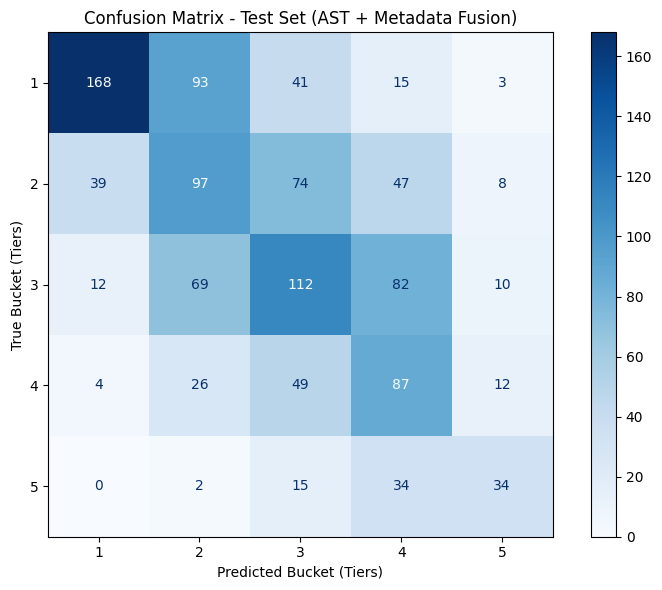

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

bucket_ranges = ["1", "2", "3", "4", "5"]
cm = confusion_matrix(all_targets, all_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=bucket_ranges)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix - Test Set (AST + Metadata Fusion)")
ax.set_xlabel("Predicted Bucket (Tiers)")
ax.set_ylabel("True Bucket (Tiers)")
plt.tight_layout()
plt.savefig("ast_confusion_matrix.png", dpi=150)
plt.show()

In [38]:
within_1 = (np.abs(all_preds - all_targets) <= 1).mean()
print(f"Within 1 of true value: {within_1:.4f} ({within_1*100:.1f}%)")

Within 1 of true value: 0.8385 (83.8%)
